In [ ]:
# Cell 1: Cấu hình mô phỏng ⚙️
import torch

class SimulationConfig:
    # === 1. Cấu hình kiến trúc & Phân cấp ===
    ALGORITHM = 'hsfl_simclr_feedback' # Tên mới
    NUM_TIERS = 3
    ENTITIES_PER_TIER = [5, 1]
    CLIENT_MAPPING = 'balanced'
    GLOBAL_ROUNDS = 20

    # === 2. Cấu hình SimCLR & Huấn luyện Local ===
    SIMCLR_EPOCHS_CLIENT = 5
    SIMCLR_EPOCHS_EDGE = 10
    SIMCLR_EPOCHS_CLOUD = 10
    PROJECTION_DIM = 128
    TEMPERATURE = 0.5
    REGULARIZATION_LAMBDA = 0.5 # <-- Tham số mới: Độ mạnh của feedback loss

    # === 3. Cấu hình Prototype & Sample Generation ===
    PROTOTYPE_METHOD = 'mean_std' # 'kmeans' or 'mean_std'
    NUM_PROTOTYPES = 50
    SAMPLE_GENERATION_METHOD = 'gaussian_sampling' # 'prototypes_as_data' or 'gaussian_sampling'
    SAMPLE_SIZE = 1000

    # === 4. Cấu hình Huấn luyện & Đánh giá ===
    BATCH_SIZE = 512
    LEARNING_RATE = 0.001
    LINEAR_PROBE_EPOCHS = 50

    # === 5. Cấu hình hệ thống & đường dẫn ===
    CONFIG_PATH = '../configs/config.yaml'
    DATA_PATH = '../data'
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED = 42

config = SimulationConfig()

# --- Kiểm tra cấu hình ---
assert len(config.ENTITIES_PER_TIER) == config.NUM_TIERS - 1
print(f"Algorithm: {config.ALGORITHM.upper()}, Feedback Lambda: {config.REGULARIZATION_LAMBDA}")

Algorithm: HSFL_SIMCLR_FEEDBACK, Feedback Lambda: 0.5


In [ ]:
# Cell 2: Tải cấu hình, dữ liệu và thiết lập cấu trúc phân cấp 📦
import yaml, torch, numpy as np, time, copy, os, collections
import matplotlib.pyplot as plt
from torch import nn
from torch.optim import Adam
import sys
sys.path.append(os.path.abspath(os.path.join('..')))
from src.dataset_preparation import prepare_data 

# --- Setup & Load Data Config ---
torch.manual_seed(config.SEED); np.random.seed(config.SEED)
print(f"Reading data config from: {config.CONFIG_PATH}")
with open(config.CONFIG_PATH, 'r') as f: loaded_config = yaml.safe_load(f)
data_params = loaded_config['data_config']
print(f"Loaded data config: {data_params}")

# --- Prepare Data ---
client_loaders, test_loader, class_names = prepare_data(
    data_path=config.DATA_PATH, batch_size=config.BATCH_SIZE, seed=config.SEED, **data_params
)
total_num_clients = len(client_loaders)
num_classes = len(class_names)
print(f"\nInitialized data for {total_num_clients} clients.")
print(f"Using device: {config.DEVICE}")

# --- Thiết lập cấu trúc phân cấp ---
entities_map = collections.defaultdict(list); client_parent_map = {}; entity_children_map = collections.defaultdict(list)
entities_map[0] = list(range(total_num_clients))
num_entities_tier2 = config.ENTITIES_PER_TIER[0]; entities_map[1] = list(range(num_entities_tier2))
client_indices_per_edge = np.array_split(np.arange(total_num_clients), num_entities_tier2)
for edge_id, client_indices in enumerate(client_indices_per_edge):
    entity_children_map[(1, edge_id)] = list(client_indices)
    for client_id in client_indices: client_parent_map[client_id] = (1, edge_id)
if config.NUM_TIERS > 2:
     num_entities_tier3 = config.ENTITIES_PER_TIER[1]; entities_map[2] = list(range(num_entities_tier3))
     entity_children_map[(2, 0)] = entities_map[1] # Cloud 0's children are all edges

print("\nHierarchical Structure:"); print(f"  - Tier 1 (Clients): {total_num_clients}")
print(f"  - Tier 2 (Edges): {num_entities_tier2}")
if config.NUM_TIERS > 2: print(f"  - Tier 3 (Cloud): {num_entities_tier3}")

Reading data config from: ../configs/config.yaml
Loaded data config: {'dataset_name': 'cifar10', 'distribution_mode': 'iid', 'num_clients': 50, 'shards_per_client': 2, 'dirichlet_alpha': 0.5}

Initialized data for 50 clients.
Using device: cuda

Hierarchical Structure:
  - Tier 1 (Clients): 50
  - Tier 2 (Edges): 5
  - Tier 3 (Cloud): 1


In [ ]:
# Cell 3: SimCLR Components 🧩
from torchvision import transforms
import torch.nn.functional as F # Ensure F is imported

# --- Data Augmentation ---
def get_simclr_transforms(input_size=32):
    # Input is now assumed to be a Tensor [C, H, W] from DataLoader
    return transforms.Compose([
        # Option A: Convert Tensor -> PIL -> Augment -> Tensor (Standard Torchvision)
        transforms.ToPILImage(), # Convert Tensor to PIL
        transforms.RandomResizedCrop(size=input_size, scale=(0.2, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
        transforms.RandomGrayscale(p=0.2),
        # Optional: Gaussian Blur
        # transforms.RandomApply([transforms.GaussianBlur(kernel_size=int(0.1 * input_size) // 2 * 2 + 1, sigma=(0.1, 2.0))], p=0.5),
        transforms.ToTensor(), # Convert augmented PIL back to Tensor
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet normalization

        # Option B (Requires Kornia or custom transforms): Augment Tensors directly
        # Add normalization first if needed by Tensor transforms
        # transforms.Normalize(...)
        # transforms.RandomResizedCrop(...) # Kornia version
        # ... other Kornia/custom Tensor transforms ...
    ])

# --- Projection Head ---
class ProjectionMLP(nn.Module):
    def __init__(self, in_features, hidden_dim=512, out_dim=128):
        super().__init__()
        if in_features <= 0: raise ValueError(f"ProjectionMLP input dim > 0, got {in_features}")
        self.mlp = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )
    def forward(self, x):
        return self.mlp(x)

# --- NT-Xent Loss ---
def nt_xent_loss(z_i, z_j, temperature):
    batch_size = z_i.shape[0]
    if batch_size == 0: return torch.tensor(0.0, device=z_i.device) # Handle empty batch
    z = torch.cat((z_i, z_j), dim=0)
    z = F.normalize(z, dim=1)
    sim_matrix = torch.mm(z, z.T) / temperature
    sim_matrix = sim_matrix - torch.eye(2 * batch_size, device=z.device) * 1e5 # Mask diagonal
    labels = torch.arange(2 * batch_size, device=z.device)
    labels = (labels + batch_size) % (2 * batch_size) # Correct labels
    loss = F.cross_entropy(sim_matrix, labels)
    return loss

In [ ]:
# Cell 4: Định nghĩa các phần mô hình 🧠
from torchvision.models import resnet18, ResNet18_Weights

def create_hsfl_resnet_parts(num_tiers=3, input_sample_shape=(2, 3, 32, 32)):
    base_model = resnet18(weights=ResNet18_Weights.DEFAULT); modules = list(base_model.children())[:-1]
    model_parts = []; flattened_feature_dims = []; unflattened_shapes = []; dummy_input = torch.randn(*input_sample_shape)
    if num_tiers == 3:
        client_part = nn.Sequential(*modules[:5]); edge_part = nn.Sequential(*modules[5:7])
        cloud_part = nn.Sequential(*modules[7], nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(1))
        model_parts = [client_part, edge_part, cloud_part]
        with torch.no_grad():
            out1 = client_part(dummy_input); unflattened_shapes.append(out1.shape[1:]); flat_dim1 = nn.Flatten(1)(out1).shape[1]; flattened_feature_dims.append(flat_dim1)
            out2 = edge_part(out1); unflattened_shapes.append(out2.shape[1:]); flat_dim2 = nn.Flatten(1)(out2).shape[1]; flattened_feature_dims.append(flat_dim2)
            out3 = cloud_part(out2); unflattened_shapes.append(None); flat_dim3 = out3.shape[1]; flattened_feature_dims.append(flat_dim3)
        print(f"Flattened feature dims: {flattened_feature_dims}"); print(f"Unflattened shapes: {unflattened_shapes}")
    else: raise NotImplementedError("Only 3 tiers supported.")
    return model_parts, flattened_feature_dims, unflattened_shapes

input_size = 64 if data_params['dataset_name'] == 'tiny_imagenet' else 32
hsfl_model_parts, feature_dims, unflattened_output_shapes = create_hsfl_resnet_parts(
    config.NUM_TIERS, input_sample_shape=(2, 3, input_size, input_size)
)

models = collections.defaultdict(list); projections = collections.defaultdict(list); optimizers = collections.defaultdict(list)

print(f"Initializing {total_num_clients} models/projections/optimizers for Tier 1...")
for i in range(total_num_clients):
    model = copy.deepcopy(hsfl_model_parts[0]).to(config.DEVICE)
    try: proj = ProjectionMLP(feature_dims[0], out_dim=config.PROJECTION_DIM).to(config.DEVICE)
    except ValueError as e: print(f"Error client proj {i}: {e}"); raise e
    optimizer = Adam(list(model.parameters()) + list(proj.parameters()), lr=config.LEARNING_RATE)
    models[0].append(model); projections[0].append(proj); optimizers[0].append(optimizer)

for tier_idx in range(1, config.NUM_TIERS):
    num_entities = len(entities_map[tier_idx])
    print(f"Initializing {num_entities} models/projections/optimizers for Tier {tier_idx+1}...")
    for i in range(num_entities):
        model = copy.deepcopy(hsfl_model_parts[tier_idx]).to(config.DEVICE)
        try: proj = ProjectionMLP(feature_dims[tier_idx], out_dim=config.PROJECTION_DIM).to(config.DEVICE)
        except ValueError as e: print(f"Error shared proj Tier {tier_idx+1}, Entity {i}: {e}"); raise e
        optimizer = Adam(list(model.parameters()) + list(proj.parameters()), lr=config.LEARNING_RATE)
        models[tier_idx].append(model); projections[tier_idx].append(proj); optimizers[tier_idx].append(optimizer)

simclr_transforms = get_simclr_transforms(input_size=input_size)

Flattened feature dims: [4096, 1024, 512]
Unflattened shapes: [torch.Size([64, 8, 8]), torch.Size([256, 2, 2]), None]
Initializing 50 models/projections/optimizers for Tier 1...
Initializing 5 models/projections/optimizers for Tier 2...
Initializing 1 models/projections/optimizers for Tier 3...


In [ ]:
# --- Imports needed for this combined cell ---
import collections
import time
import random
import torch
import numpy as np
from tqdm import tqdm # Or use 'from tqdm import tqdm' if not in notebook
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.cluster import KMeans
from itertools import islice

# =====================================================================================
# CELL 5: Helper Functions (Feedback Version) 🛠️
# =====================================================================================

# --- Helper to calculate tensor size ---
def calculate_tensor_size_mb(data_to_measure):
    """Calculates size of tensor or dict of tensors in MB."""
    total_size_mb = 0
    if data_to_measure is None: return 0
    elif isinstance(data_to_measure, torch.Tensor):
        total_size_mb = data_to_measure.element_size()*data_to_measure.nelement()/(1024**2)
    elif isinstance(data_to_measure, dict):
        for key, tensor in data_to_measure.items():
            if isinstance(tensor, torch.Tensor): total_size_mb += tensor.element_size()*tensor.nelement()/(1024**2)
    else: print(f"Warn: Cannot calc size for {type(data_to_measure)}.")
    return total_size_mb

# --- Prototype Calculation (Handles both 'h' and 'z') ---
@torch.no_grad()
def compute_prototypes(model, projection_head, data_loader, method='kmeans', k=50, compute_on_z=False):
    """
    Computes prototypes or statistics.
    If compute_on_z=True, runs data through model AND projection_head.
    Otherwise, runs data only through model.
    """
    if model is None and not compute_on_z: print("Error: Model None required for h-protos."); return None
    if compute_on_z and (model is None or projection_head is None): print("Error: Model & Proj needed for z-protos."); return None

    if model: model.eval()
    if projection_head and compute_on_z: projection_head.eval()

    all_features_flat_list = []; flattener = nn.Flatten(1).to(config.DEVICE)

    for i, batch_data in enumerate(data_loader):
        if isinstance(batch_data, (list, tuple)): data = batch_data[0].to(config.DEVICE)
        else: data = batch_data.to(config.DEVICE)
        try:
            # Always run base model to get 'h'
            if model is None: print("Error: Model is None."); continue
            features_h = model(data)
            features_h_flat = flattener(features_h)

            # Optionally run projection head
            if compute_on_z:
                if projection_head is None: print("Error: projection_head needed."); continue
                if features_h_flat.shape[1] != projection_head.mlp[0].in_features:
                     print(f"Error: Dim mismatch proto calc proj head. Got {features_h_flat.shape[1]}, expected {projection_head.mlp[0].in_features}. Skip batch.")
                     continue
                features_to_use = projection_head(features_h_flat) # Use 'z'
            else:
                features_to_use = features_h_flat # Use 'h'

            all_features_flat_list.append(features_to_use.detach().cpu().numpy())
        except Exception as e: print(f"  Error proto feature process: {e}. Input: {data.shape}. Skip batch."); continue

    if not all_features_flat_list: print("Warn: No features collected for protos."); return None
    try: all_features_flat = np.concatenate(all_features_flat_list, axis=0)
    except ValueError as e: print(f"Error concat features: {e}."); return None

    num_samples = all_features_flat.shape[0]
    if num_samples < k and method == 'kmeans': k = max(1, num_samples)

    if method == 'kmeans':
        if k <= 0: print("Warn: k=0 KMeans."); return None
        if num_samples == 0: print("Warn: No features KMeans."); return None
        kmeans = KMeans(n_clusters=k, random_state=config.SEED, n_init='auto', verbose=0)
        try: kmeans.fit(all_features_flat); return torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)
        except Exception as e: print(f"Error KMeans fit: {e}. Shape: {all_features_flat.shape}"); return None
    elif method == 'mean_std':
        if num_samples == 0: print("Warn: No features mean/std."); return None
        mean = np.mean(all_features_flat, axis=0); std = np.std(all_features_flat, axis=0)
        if mean.shape != std.shape: std = np.zeros_like(mean)
        return {'mean': torch.tensor(mean, dtype=torch.float32), 'std': torch.tensor(std, dtype=torch.float32)}
    else: raise ValueError("Invalid proto method.")

# --- Sample Generation ---
def generate_samples(prototypes_or_stats, num_samples, method='prototypes_as_data'):
    """Generates synthetic samples."""
    if prototypes_or_stats is None: print("Warn: Protos/stats None."); return None
    if method == 'prototypes_as_data':
        if not isinstance(prototypes_or_stats, torch.Tensor) or prototypes_or_stats.numel()==0: print("Warn: Invalid protos."); return None
        num_available = len(prototypes_or_stats);
        if num_available == 0: print("Warn: No protos."); return None
        indices = np.random.choice(num_available, num_samples, replace=True); return prototypes_or_stats[indices]
    elif method == 'gaussian_sampling':
        if not isinstance(prototypes_or_stats, list) or not prototypes_or_stats: print("Warn: Invalid stats list."); return None
        all_samples = []
        valid_distributions = [item for item in prototypes_or_stats if isinstance(item, dict) and 'mean' in item and 'std' in item and item['mean'] is not None and item['std'] is not None]
        num_valid_distributions = len(valid_distributions)
        if num_valid_distributions == 0: print("Warn: No valid distributions for Gaussian sampling."); return None
        samples_per_dist = num_samples // num_valid_distributions; remainder = num_samples % num_valid_distributions
        valid_dist_count = 0
        for i, stats_dict in enumerate(valid_distributions): # Iterate only valid ones
            mean = stats_dict['mean']; std = stats_dict['std']
            n_samples_this = samples_per_dist + (1 if valid_dist_count < remainder else 0);
            valid_dist_count += 1
            if n_samples_this == 0: continue
            samples = torch.randn(n_samples_this, len(mean), device=mean.device) * std.clamp(min=1e-6) + mean; all_samples.append(samples)
        if not all_samples: print("Warn: Gaussian sampling no samples."); return None
        return torch.cat(all_samples, dim=0)
    else: raise ValueError("Invalid sample gen method.")

# --- Alignment Loss (Works on Projected Space 'z') ---
def alignment_loss(features_z, parent_data_z, method):
    """Calculates alignment loss between batch features z and parent projected protos/stats P_z."""
    if parent_data_z is None or features_z is None or features_z.numel() == 0: return torch.tensor(0.0).to(config.DEVICE)
    feature_dim = features_z.shape[1]
    parent_dim = -1
    if method == 'kmeans':
        if not isinstance(parent_data_z, torch.Tensor) or parent_data_z.numel() == 0: print("Warn: Invalid parent KMeans align data."); return torch.tensor(0.0).to(config.DEVICE)
        parent_protos_z = parent_data_z.to(features_z.device); parent_dim = parent_protos_z.shape[1]
        if feature_dim != parent_dim: print(f"Warn: Align loss dim mismatch z ({feature_dim}) vs P_z ({parent_dim}). Skip."); return torch.tensor(0.0).to(config.DEVICE)
        dist_matrix = torch.cdist(features_z, parent_protos_z, p=2.0)**2; min_dists, _ = torch.min(dist_matrix, dim=1); return torch.mean(min_dists)
    elif method == 'mean_std':
        if not isinstance(parent_data_z, dict) or 'mean' not in parent_data_z: print("Warn: Invalid parent Mean/Std align data."); return torch.tensor(0.0).to(config.DEVICE)
        parent_mean_z = parent_data_z['mean'].to(features_z.device); parent_dim = parent_mean_z.shape[0]
        if feature_dim != parent_dim: print(f"Warn: Align loss dim mismatch z ({feature_dim}) vs P_mean_z ({parent_dim}). Skip."); return torch.tensor(0.0).to(config.DEVICE)
        batch_mean_z = torch.mean(features_z, dim=0); return torch.norm(batch_mean_z - parent_mean_z, p=2)
    else: return torch.tensor(0.0).to(config.DEVICE)

# --- SimCLR Training Loop (Includes Alignment Loss) ---
def simclr_train_loop(model, projection, optimizer, data_source, epochs, is_real_data=True,
                      expected_input_shape=None, parent_projected_data=None, reg_lambda=0.0):
    """Inner training loop for SimCLR with optional feedback alignment loss."""
    model.train(); projection.train(); losses = []; flattener = nn.Flatten(1).to(config.DEVICE)
    for epoch in range(epochs):
        epoch_loss = 0.0; num_batches = 0
        if is_real_data: data_iterator = tqdm(data_source, desc=f"SimCLR Ep {epoch+1}/{epochs}", leave=False); num_batches = len(data_source)
        else:
            if data_source is None or data_source.numel() == 0: print(f"  Skip Ep {epoch+1}: No data."); continue
            pseudo_dataset = TensorDataset(data_source); pseudo_loader = DataLoader(pseudo_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
            data_iterator = tqdm(pseudo_loader, desc=f"SimCLR Ep {epoch+1}/{epochs}", leave=False); num_batches = len(pseudo_loader)
        if num_batches == 0: print(f"  Skip Ep {epoch+1}: Empty loader."); continue

        for i, batch in enumerate(data_iterator):
            optimizer.zero_grad()
            total_loss = torch.tensor(0.0).to(config.DEVICE)
            try:
                if is_real_data:
                    images, _ = batch; # Tensors [B, C, H, W]
                    # Pass Tensors directly to simclr_transforms (which starts with ToPILImage)
                    img1 = torch.stack([simclr_transforms(img) for img in images]).to(config.DEVICE)
                    img2 = torch.stack([simclr_transforms(img) for img in images]).to(config.DEVICE)
                else: # Generated Features - Reshape needed
                    features = batch[0].to(config.DEVICE); current_batch_size = features.shape[0]
                    if expected_input_shape is None: raise ValueError("expected_input_shape required if not real data")
                    try: reshaped_features = features.view(current_batch_size, *expected_input_shape)
                    except RuntimeError as e: print(f"  Error reshaping: {e}. Skip batch."); continue
                    noise1 = torch.randn_like(reshaped_features)*0.01; noise2 = torch.randn_like(reshaped_features)*0.01
                    img1 = reshaped_features + noise1; img2 = reshaped_features + noise2

                # Forward pass model -> projection
                h1 = model(img1); h2 = model(img2);
                if h1.dim() > 2: h1_flat = flattener(h1); h2_flat = flattener(h2)
                else: h1_flat, h2_flat = h1, h2
                z1 = projection(h1_flat); z2 = projection(h2_flat) # Get z vectors

                # 1. SimCLR Loss (NT-Xent) on z vectors
                loss_simclr = nt_xent_loss(z1, z2, config.TEMPERATURE)
                total_loss += loss_simclr

                # 2. Feedback Alignment Loss (on z vectors)
                if parent_projected_data is not None and reg_lambda > 0:
                     loss_align = alignment_loss(torch.cat([z1, z2], dim=0), parent_projected_data, config.PROTOTYPE_METHOD)
                     total_loss += reg_lambda * loss_align

                # Backward and update
                if not torch.isnan(total_loss) and not torch.isinf(total_loss) and total_loss.requires_grad:
                     total_loss.backward(); optimizer.step()
                     epoch_loss += total_loss.item(); data_iterator.set_postfix(loss=total_loss.item())
                else: print(f"  Warn: Invalid loss ({total_loss.item()}) or no grad. Skipping step.")

            except Exception as e: print(f"  Error SimCLR batch {i}: {e}. Skip."); continue
        avg_loss = epoch_loss / max(num_batches, 1); losses.append(avg_loss)
    return losses

# --- Linear Probing Evaluation ---
@torch.no_grad()
def encode_data(all_models, data_loader):
    """Encodes data through the entire model chain."""
    for m in all_models: m.eval(); all_features, all_labels = [], []
    data_iterator = data_loader if isinstance(data_loader, DataLoader) else data_loader
    for data_batch in tqdm(data_iterator, desc="Encoding data", leave=False):
        labels=None
        if isinstance(data_batch,(list,tuple)): data=data_batch[0].to(config.DEVICE); labels=data_batch[1] if len(data_batch)>1 else None
        else: data=data_batch.to(config.DEVICE)
        features = data
        try:
            for model in all_models: features = model(features)
            all_features.append(features.detach().cpu())
            if labels is not None: all_labels.append(labels.cpu())
        except Exception as e: print(f"  Error encoding batch: {e}. Skip."); continue
    if not all_features: return None, None
    try: final_features = torch.cat(all_features); final_labels = torch.cat(all_labels) if all_labels else None
    except RuntimeError as e: print(f"Error concat encoded: {e}"); return None, None
    return final_features, final_labels

def evaluate_linear_probe(train_features, train_labels, test_features, test_labels):
    """Trains and evaluates a linear classifier."""
    if train_features is None or train_labels is None or test_features is None or test_labels is None: print("Linear Probe skipped: Missing data."); return 0.0
    if len(train_features) == 0 or len(test_features) == 0: print("Linear Probe skipped: Empty features."); return 0.0
    if len(train_features) != len(train_labels): print(f"Linear Probe skipped: Mismatched train ({len(train_features)} vs {len(train_labels)})."); return 0.0
    if len(test_features) != len(test_labels): print(f"Linear Probe skipped: Mismatched test ({len(test_features)} vs {len(test_labels)})."); return 0.0

    input_dim = train_features.shape[1]; global num_classes
    linear_clf = nn.Linear(input_dim, num_classes).to(config.DEVICE); clf_optimizer = Adam(linear_clf.parameters(), lr=0.01); clf_criterion = nn.CrossEntropyLoss()
    train_dataset = TensorDataset(train_features, train_labels); probe_batch_size = min(512, len(train_dataset))
    if probe_batch_size == 0: print("Linear Probe skipped: Train dataset empty."); return 0.0
    train_loader = DataLoader(train_dataset, batch_size=probe_batch_size, shuffle=True)

    print("Training Linear Probe..."); linear_clf.train()
    for epoch in range(config.LINEAR_PROBE_EPOCHS):
        for features, labels in train_loader:
            features, labels = features.to(config.DEVICE), labels.to(config.DEVICE); clf_optimizer.zero_grad()
            logits = linear_clf(features); loss = clf_criterion(logits, labels); loss.backward(); clf_optimizer.step()

    linear_clf.eval(); correct = 0; total = 0
    test_dataset = TensorDataset(test_features, test_labels); test_loader_probe = DataLoader(test_dataset, batch_size=512)
    with torch.no_grad():
         for features, labels in test_loader_probe:
              features, labels = features.to(config.DEVICE), labels.to(config.DEVICE)
              logits = linear_clf(features); preds = logits.argmax(dim=1); correct += (preds == labels).sum().item(); total += labels.size(0)
    accuracy = 100. * correct / total if total > 0 else 0.0; print(f"Linear Probe Test Accuracy: {accuracy:.2f}%"); return accuracy

# --- get_entity_id function ---
def get_entity_id(tier_idx, client_id):
    """Gets entity ID for a client at a specific tier."""
    if tier_idx == 0: return client_id
    elif tier_idx == 1:
        if client_id in client_parent_map:
            parent_tier, parent_id = client_parent_map[client_id];
            if parent_tier == 1: return parent_id
            else: print(f"Warn: Client {client_id} parent not Tier 2."); return 0
        else: print(f"Warn: Client {client_id} not in map."); return 0
    else: # Higher tiers (Cloud)
        num_entities_this_tier = len(entities_map.get(tier_idx, []))
        if num_entities_this_tier >= 1: return 0 # Assume first entity
        else: print(f"Error: No entities defined for Tier {tier_idx+1}."); return None # Indicate error

In [ ]:
# Initialize history dictionary
history = {'rounds': [], 'accuracy': [], 'comm_cost': [], 'comp_cost': []}
print(f"\n--- BẮT ĐẦU MÔ PHỎNG: {config.ALGORITHM.upper()} ---")

# --- Initialize feedback storage (stores PROJECTED protos/stats 'z' from PREVIOUS round) ---
parent_feedback_data = collections.defaultdict(lambda: [])
parent_feedback_data[1] = [None] * len(entities_map[1]) # Feedback FOR Clients FROM Edges
if config.NUM_TIERS > 2:
    parent_feedback_data[2] = [None] * len(entities_map[2]) # Feedback FOR Edges FROM Cloud

# --- Global Training Loop ---
for current_round in range(1, config.GLOBAL_ROUNDS + 1):
    if config.DEVICE.type == 'cuda': torch.cuda.empty_cache()
    round_start_time = time.time()
    print(f"\n--- Global Round {current_round}/{config.GLOBAL_ROUNDS} ---")
    comm_cost_round = 0.0; round_comp_cost = 0.0
    # Store 'h' protos/stats calculated THIS round to be sent UP
    current_upward_protos_h = collections.defaultdict(list) # {tier_idx: [{'parent_id':id, 'data':proto_h},...]}

    # --- Tier 1: Client Training & Proto Calc (Uses 'z' feedback from previous round edge) ---
    print("  Tầng 1 (Client): Huấn luyện SimCLR...")
    client_train_start_time = time.time()
    for client_id in tqdm(range(total_num_clients), desc="Client Training", leave=False):
        if config.DEVICE.type == 'cuda' and client_id > 0 and client_id % 10 == 0: torch.cuda.empty_cache()
        model = models[0][client_id]; proj = projections[0][client_id]; optimizer = optimizers[0][client_id]
        loader = client_loaders[client_id]
        parent_tier, parent_id = client_parent_map.get(client_id, (None, None))
        parent_data_for_client_z = parent_feedback_data[1][parent_id] if parent_id is not None and parent_id < len(parent_feedback_data[1]) else None

        simclr_train_loop(
            model, proj, optimizer, loader, config.SIMCLR_EPOCHS_CLIENT, is_real_data=True,
            parent_projected_data=parent_data_for_client_z, reg_lambda=config.REGULARIZATION_LAMBDA
        )
        # Compute 'h' protos/stats to send UP (compute_on_z=False)
        proto_h = compute_prototypes(model, None, loader, config.PROTOTYPE_METHOD, k=config.NUM_PROTOTYPES, compute_on_z=False)
        if proto_h is not None and parent_id is not None:
             current_upward_protos_h[0].append({'parent_id': parent_id, 'data': proto_h})
    round_comp_cost += (time.time() - client_train_start_time)

    # --- Communication: Client -> Edge (Send 'h' protos) ---
    print("  Giao tiếp: Client -> Edge...")
    edge_received_data_h = collections.defaultdict(list)
    for output in current_upward_protos_h[0]:
        parent_id = output['parent_id']; data = output['data']
        edge_received_data_h[parent_id].append(data); comm_cost_round += calculate_tensor_size_mb(data)
    # No TOR shuffling

    # --- Tier 2: Edge Training & Proto Calc (Uses 'z' feedback from previous round cloud) ---
    print(f"  Tầng 2 (Edge): Sample Generation & SimCLR Training...")
    current_edge_feedback_z = [None] * len(entities_map[1]) # Store NEW feedback ('z') FROM edges TO send DOWN
    current_edge_upward_h = [] # Store NEW 'h' protos FROM edges TO send UP
    edge_train_start_time = time.time()
    for edge_id in tqdm(entities_map[1], desc="Edge Training", leave=False):
         if config.DEVICE.type == 'cuda' and edge_id > 0 and edge_id % 5 == 0: torch.cuda.empty_cache()
         if not edge_received_data_h[edge_id]: print(f"  Skip Edge {edge_id}: No data."); continue
         # Prepare data_for_sampling from client 'h' protos
         data_for_sampling = None; received_list_h = edge_received_data_h[edge_id]
         # ... (logic to create data_for_sampling from received_list_h) ...
         if config.PROTOTYPE_METHOD == 'kmeans':
             valid_protos = [p for p in received_list_h if isinstance(p, torch.Tensor)]
             if valid_protos:
                 try: data_for_sampling = torch.cat(valid_protos, dim=0)
                 except Exception as e: print(f"  Error concat KMeans Edge {edge_id}: {e}. Skip."); continue
             else: print(f"  Warn: Edge {edge_id} no valid KMeans."); continue
         elif config.PROTOTYPE_METHOD == 'mean_std':
             all_means = [d['mean'].unsqueeze(0) for d in received_list_h if isinstance(d, dict) and 'mean' in d and isinstance(d['mean'], torch.Tensor)]
             if all_means:
                 try: data_for_sampling = torch.cat(all_means, dim=0)
                 except Exception as e: print(f"  Error concat Means Edge {edge_id}: {e}. Skip."); continue
             else: print(f"  Warn: Edge {edge_id} no valid Means."); continue
         if data_for_sampling is None or data_for_sampling.numel() == 0: print(f"  Warn: No sampling data Edge {edge_id}. Skip."); continue
         # Generate Samples based on client 'h' protos
         num_samples = data_for_sampling.shape[0] * 100
         input_for_gen = received_list_h if config.SAMPLE_GENERATION_METHOD=='gaussian_sampling' else data_for_sampling
         gen_features = generate_samples(input_for_gen, num_samples, config.SAMPLE_GENERATION_METHOD)
         if gen_features is None: print(f"  Warn: Sample gen failed Edge {edge_id}. Skip."); continue
         gen_features = gen_features.to(config.DEVICE)
         # Train Edge SimCLR
         model = models[1][edge_id]; proj = projections[1][edge_id]; optimizer = optimizers[1][edge_id]
         expected_shape_for_edge_input = unflattened_output_shapes[0] # Client output shape
         # Get feedback ('z' data from cloud, calculated in PREVIOUS round)
         parent_data_for_edge_z = parent_feedback_data[2][0] if config.NUM_TIERS > 2 and len(parent_feedback_data[2]) > 0 else None # Assumes cloud_id 0

         simclr_train_loop(
             model, proj, optimizer, gen_features, config.SIMCLR_EPOCHS_EDGE, is_real_data=False,
             expected_input_shape=expected_shape_for_edge_input,
             parent_projected_data=parent_data_for_edge_z, # Pass 'z' feedback
             reg_lambda=config.REGULARIZATION_LAMBDA
         )
         # Compute Edge Prototypes ('h' for upward, 'z' for downward)
         reshaped_gen_features_for_proto = None
         try: reshaped_gen_features_for_proto = gen_features.view(gen_features.shape[0], *expected_shape_for_edge_input)
         except RuntimeError as e: print(f"  Error reshaping Edge {edge_id} proto: {e}.")
         if reshaped_gen_features_for_proto is not None:
              pseudo_ds = TensorDataset(reshaped_gen_features_for_proto); pseudo_loader = DataLoader(pseudo_ds, batch_size=config.BATCH_SIZE)
              # Compute 'h' protos for sending UP (runs edge model on reshaped client output features)
              proto_h = compute_prototypes(model, None, pseudo_loader, config.PROTOTYPE_METHOD, k=config.NUM_PROTOTYPES, compute_on_z=False)
              if proto_h is not None: current_edge_upward_h.append({'parent_id': 0, 'data': proto_h}) # Assume cloud 0
              # Compute 'z' protos for sending DOWN (runs edge model + edge projection head)
              proto_z = compute_prototypes(model, proj, pseudo_loader, config.PROTOTYPE_METHOD, k=config.NUM_PROTOTYPES, compute_on_z=True)
              if proto_z is not None: current_edge_feedback_z[edge_id] = proto_z # Store 'z' feedback
    round_comp_cost += (time.time() - edge_train_start_time)

    # --- Communication: Edge -> Cloud (Send 'h' protos) ---
    current_cloud_feedback_z = [None] * len(entities_map[2]) if config.NUM_TIERS > 2 else [] # Store NEW feedback ('z') FROM cloud
    if config.NUM_TIERS > 2:
        print("  Communication: Edge -> Cloud...")
        cloud_received_data_h = [] # Cloud receives 'h' protos from Edges
        for output in current_edge_upward_h: # Use the NEWLY calculated edge 'h' protos
             data = output['data']
             if data is not None: cloud_received_data_h.append(data); comm_cost_round += calculate_tensor_size_mb(data)
        # No TOR

        # --- Tier 3: Cloud Training & Proto Calc ---
        print(f"  Tier 3 (Cloud): Sample Generation & SimCLR Training...")
        cloud_train_start_time = time.time()
        if cloud_received_data_h:
            data_for_sampling_cloud = None
            # ... (logic to create data_for_sampling_cloud from cloud_received_data_h) ...
            if config.PROTOTYPE_METHOD == 'kmeans':
                 valid_protos = [p for p in cloud_received_data_h if isinstance(p, torch.Tensor)]
                 if valid_protos:
                     try: data_for_sampling_cloud = torch.cat(valid_protos, dim=0)
                     except Exception as e: print(f"  Error concat KMeans Cloud: {e}")
                 else: print(f"  Warn: Cloud no valid KMeans.")
            elif config.PROTOTYPE_METHOD == 'mean_std':
                 all_means = [d['mean'].unsqueeze(0) for d in cloud_received_data_h if isinstance(d, dict) and 'mean' in d and isinstance(d['mean'], torch.Tensor)]
                 if all_means:
                     try: data_for_sampling_cloud = torch.cat(all_means, dim=0)
                     except Exception as e: print(f"  Error concat Means Cloud: {e}")
                 else: print(f"  Warn: Cloud no valid Means.")

            if data_for_sampling_cloud is not None and data_for_sampling_cloud.numel() > 0:
                 num_samples = data_for_sampling_cloud.shape[0] * 100
                 input_for_gen_cloud = cloud_received_data_h if config.SAMPLE_GENERATION_METHOD=='gaussian_sampling' else data_for_sampling_cloud
                 gen_features_cloud = generate_samples(input_for_gen_cloud, num_samples, config.SAMPLE_GENERATION_METHOD)
                 if gen_features_cloud is not None:
                     gen_features_cloud = gen_features_cloud.to(config.DEVICE)
                     cloud_model = models[2][0]; cloud_proj = projections[2][0]; cloud_optimizer = optimizers[2][0]
                     expected_shape_for_cloud_input = unflattened_output_shapes[1] # Edge output shape
                     # Cloud is top tier, no parent_data for regularization
                     simclr_train_loop(
                         cloud_model, cloud_proj, cloud_optimizer, gen_features_cloud, config.SIMCLR_EPOCHS_CLOUD,
                         is_real_data=False, expected_input_shape=expected_shape_for_cloud_input,
                         parent_projected_data=None, reg_lambda=0.0 # No feedback needed
                     )
                     # Compute Cloud Prototypes ('z') to send DOWN next round
                     f = None
                     try: reshaped_gen_features_cloud_for_proto = gen_features_cloud.view(gen_features_cloud.shape[0], *expected_shape_for_cloud_input)
                     except RuntimeError as e: print(f"  Error reshaping Cloud proto: {e}.")
                     if reshaped_gen_features_cloud_for_proto is not None:
                         pseudo_ds_cloud = TensorDataset(reshaped_gen_features_cloud_for_proto)
                         pseudo_loader_cloud = DataLoader(pseudo_ds_cloud, batch_size=config.BATCH_SIZE)
                         proto_z_cloud = compute_prototypes(cloud_model, cloud_proj, pseudo_loader_cloud, config.PROTOTYPE_METHOD, k=config.NUM_PROTOTYPES, compute_on_z=True) # Compute on 'z'
                         if proto_z_cloud is not None: current_cloud_feedback_z[0] = proto_z_cloud # Store 'z' feedback

                 else: print("  Warn: Sample gen failed Cloud.")
            else: print("  Warn: No sampling data Cloud.")
        else: print("  Skipping Cloud training: No data received.")
        round_comp_cost += (time.time() - cloud_train_start_time)

    # --- Update Feedback Data for NEXT round ---
    # The data calculated THIS round becomes the parent data for the NEXT round
    parent_feedback_data[1] = current_edge_feedback_z # Edges provide z-feedback to clients next round
    if config.NUM_TIERS > 2:
        parent_feedback_data[2] = current_cloud_feedback_z # Cloud provides z-feedback to edges next round

    # --- Evaluation (Linear Probing) ---
    print("  Evaluation (Linear Probing)...")
    eval_start_time = time.time()
    # ... (Evaluation logic remains the same) ...
    eval_models_encode = [models[0][0]] # Client 0 model path
    valid_eval_path = True
    for tier_idx in range(1, config.NUM_TIERS):
         entity_id = get_entity_id(tier_idx, 0)
         if entity_id is not None and entity_id < len(models[tier_idx]): eval_models_encode.append(models[tier_idx][entity_id])
         else: print(f"Error: Eval entity ID {entity_id} invalid Tier {tier_idx+1}."); valid_eval_path = False; break
    accuracy = 0.0
    if valid_eval_path:
        probe_train_loader = None;
        try:
            _ = client_loaders[0].dataset[0]; ds_len = len(client_loaders[0].dataset)
            subset_indices = list(range(ds_len))[:min(10000, ds_len)]
            if subset_indices:
                 subset_sampler = torch.utils.data.SubsetRandomSampler(subset_indices)
                 probe_train_loader = DataLoader(client_loaders[0].dataset, batch_size=config.BATCH_SIZE, sampler=subset_sampler)
            else: print("Warn: Client 0 dataset empty?")
        except TypeError:
            print("  Warn: Using first batches probe train (IterableDataset).")
            probe_train_loader = list(islice(client_loaders[0], max(1, 10000 // config.BATCH_SIZE)))
            if not probe_train_loader: print("Warn: Could not get probe batches.")
        if probe_train_loader:
             train_features, train_labels = encode_data(eval_models_encode, probe_train_loader)
             test_features, test_labels = encode_data(eval_models_encode, test_loader)
             if train_features is not None and train_labels is not None and test_features is not None and test_labels is not None:
                  accuracy = evaluate_linear_probe(train_features, train_labels, test_features, test_labels)
             else: print("Skipping evaluation: Feature encoding failed.")
        else: print("Skipping evaluation: Could not create probe loader.")
    round_comp_cost += (time.time() - eval_start_time)

    # --- Log History ---
    round_elapsed_time = time.time() - round_start_time
    history['rounds'].append(current_round); history['accuracy'].append(accuracy)
    history['comm_cost'].append(comm_cost_round)
    history['comp_cost'].append(round_comp_cost)
    # history['ram_usage'].append(round_peak_ram)
    # history['gpu_usage'].append(round_peak_gpu)

    print(f"--- Global Round {current_round:02d} Summary ---")
    print(f"  Accuracy (Linear Probe): {accuracy:.2f}%")
    print(f"  Est. Comp Cost: {round_comp_cost:.2f} s")
    print(f"  Est. Comm Cost: {comm_cost_round:.2f} MB")
    print(f"  Round Time: {round_elapsed_time:.2f} s")

print("\n--- SIMULATION COMPLETE ---")
# shutdown_pynvml()


--- BẮT ĐẦU MÔ PHỎNG: HSFL_SIMCLR_FEEDBACK ---

--- Global Round 1/20 ---
  Tầng 1 (Client): Huấn luyện SimCLR...


  Giao tiếp: Client -> Edge...
  Tầng 2 (Edge): Sample Generation & SimCLR Training...


  Communication: Edge -> Cloud...
  Tier 3 (Cloud): Sample Generation & SimCLR Training...


  Evaluation (Linear Probing)...


Training Linear Probe...
Linear Probe Test Accuracy: 34.90%
--- Global Round 01 Summary ---
  Accuracy (Linear Probe): 34.90%
  Est. Comp Cost: 297.30 s
  Est. Comm Cost: 1.60 MB
  Round Time: 297.30 s

--- Global Round 2/20 ---
  Tầng 1 (Client): Huấn luyện SimCLR...


...

Training Linear Probe...
Linear Probe Test Accuracy: 25.65%
--- Global Round 19 Summary ---
  Accuracy (Linear Probe): 25.65%
  Est. Comp Cost: 278.22 s
  Est. Comm Cost: 1.60 MB
  Round Time: 278.22 s

--- Global Round 20/20 ---
  Tầng 1 (Client): Huấn luyện SimCLR...


  Giao tiếp: Client -> Edge...
  Tầng 2 (Edge): Sample Generation & SimCLR Training...


  Communication: Edge -> Cloud...
  Tier 3 (Cloud): Sample Generation & SimCLR Training...


  Evaluation (Linear Probing)...


Training Linear Probe...
Linear Probe Test Accuracy: 26.13%
--- Global Round 20 Summary ---
  Accuracy (Linear Probe): 26.13%
  Est. Comp Cost: 278.73 s
  Est. Comm Cost: 1.60 MB
  Round Time: 278.73 s

--- SIMULATION COMPLETE ---


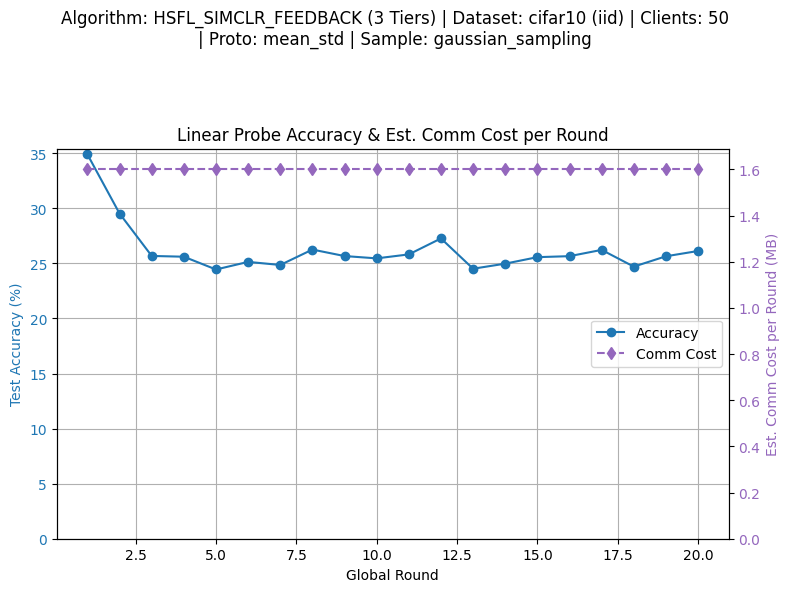

In [ ]:
# Cell 7: Plot Results 📊
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
title = (f"Algorithm: {config.ALGORITHM.upper()} ({config.NUM_TIERS} Tiers) | Dataset: {data_params['dataset_name']} "
         f"({data_params['distribution_mode']}) | Clients: {total_num_clients}\n"
         f"| Proto: {config.PROTOTYPE_METHOD} | Sample: {config.SAMPLE_GENERATION_METHOD}")
fig.suptitle(title, fontsize=12)
rounds = history['rounds']

# Plot Accuracy
ax_acc = ax
ax_acc.plot(rounds, history['accuracy'], marker='o', color='tab:blue', label='Accuracy')
ax_acc.set_title("Linear Probe Accuracy & Est. Comm Cost per Round")
ax_acc.set_xlabel("Global Round")
ax_acc.set_ylabel("Test Accuracy (%)", color='tab:blue')
ax_acc.tick_params(axis='y', labelcolor='tab:blue')
ax_acc.grid(True)
ax_acc.set_ylim(bottom=0)

# Plot Communication Cost on secondary y-axis
ax_comm = ax_acc.twinx() # instantiate a second axes that shares the same x-axis
ax_comm.plot(rounds, history['comm_cost'], marker='d', color='tab:purple', linestyle='--', label='Comm Cost')
ax_comm.set_ylabel('Est. Comm Cost per Round (MB)', color='tab:purple')
ax_comm.tick_params(axis='y', labelcolor='tab:purple')
ax_comm.set_ylim(bottom=0)

# Add legends
lines_acc, labels_acc = ax_acc.get_legend_handles_labels()
lines_comm, labels_comm = ax_comm.get_legend_handles_labels()
ax_comm.legend(lines_acc + lines_comm, labels_acc + labels_comm, loc='center right')

plt.tight_layout(rect=[0, 0, 1, 0.90]) # Adjust layout
plt.show()